# Auto Calibration — QickworkspaceV2

This notebook demonstrates the full automated single-qubit ge calibration pipeline.

| Cell | What it covers |
| --- | --- |
| 1 | Imports & setup |
| 2 | `CalibrationStore` — load / inspect |
| 3 | `CalibrationGraph` — visualise the DAG |
| 4 | `CalibrationMonitor` — background staleness watcher |
| 5 | `AutoCalibrate` — full 7-step pipeline |
| 6 | Results dashboard |
| 7 | Offline / `SimulatedBackend` demo |


---
## 1 — Imports & hardware setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from datetime import datetime

from QickworkspaceV2 import (
    SimulatedBackend, ExperimentConfig,
    CalibrationStore, CalibrationGraph, CalibrationNode, CalibrationMonitor,
    AutoCalibrate,
)
from QickworkspaceV2.core.base_experiment import BaseExperiment
from QickworkspaceV2.config.system_cfg import config_list

print('QickworkspaceV2 loaded')

QickworkspaceV2 loaded


In [2]:
# ── Hardware: choose ONE of the two blocks below ──────────────────────────────

# ── Option A: Real QICK hardware ─────────────────────────��───────────────────
# from QickworkspaceV2.backend.qick_backend import QICKBackend
# backend = QICKBackend.from_pyro4('192.168.10.82', 8888)
# backend.activate()
# DATA_PATH = r'D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature'
# BaseExperiment.setup(backend._soc, backend._soccfg, DATA_PATH)

# ── Option B: SimulatedBackend (offline, no hardware needed) ──────────────────
backend = SimulatedBackend(noise_level=0.02)
backend.activate()

# ── Config ────────────────────────────────────────────────────────────────────
qubit      = 'Q1'
config_all = ExperimentConfig(config_list)
run_cfg    = config_all.get_qubit(qubit)

# Centralised initial guesses for auto calibration.
# Tuple format: (start, stop, points).  For time axes use us.
init_guess = {
    'res': (run_cfg['res_freq_ge'] - 10, run_cfg['res_freq_ge'] + 10, 101),
    'qb':  (run_cfg['qb_freq_ge'] - 50,  run_cfg['qb_freq_ge'] + 50,  101),
    'rabi': (0.0, 1.0, 100),
    'sigma': run_cfg.get('sigma_ge', 0.01),
    'T1_guess': 50.0,
    'T2_guess': 40.0,
    't1': (0.0, 150.0, 100),
    'ramsey': (0.0, 15.0, 100),
    'spin_echo': (0.0, 200.0, 100),
    'ramsey_freq': 2.0,
}

# ── Calibration Store ─────────────────────────────────────────────────────────
STORE_PATH = f'cal_{qubit}.json'
store      = CalibrationStore(STORE_PATH, default_max_age_hours=24)

print(f'Qubit  : {qubit}')
print(f'Store  : {STORE_PATH}')
print(f'Backend: {backend.__class__.__name__}')

[SimulatedBackend] Session activated (no hardware required)
Qubit  : Q1
Store  : cal_Q1.json
Backend: SimulatedBackend


---
## 2 — CalibrationStore: inspect current state

In [3]:
def show_store(store: CalibrationStore, qubit: str):
    """Print all stored parameters with age and freshness."""
    params = store.to_flat_dict(qubit)
    if not params:
        print(f'  [{qubit}] store is empty — run calibration first.')
        return
    now = datetime.now()
    print(f'\n  Calibration Store  —  {qubit}')
    print(f'  {"Key":<28s}  {"Value":<18s}  {"Age":<14s}  Status')
    print('  ' + '-'*78)
    for key, meta in store._store.get(qubit, {}).items():
        val  = meta['value']
        ts   = datetime.fromisoformat(meta['timestamp'])
        age  = now - ts
        age_h = age.total_seconds() / 3600
        fresh = '✓ fresh' if age_h < 24 else '⚠ stale'
        val_str = f'{val:.5g}' if isinstance(val, float) else str(val)
        age_str = f'{age_h:.1f}h'
        print(f'  {key:<28s}  {val_str:<18s}  {age_str:<14s}  {fresh}')

show_store(store, qubit)


  Calibration Store  —  Q1
  Key                           Value               Age             Status
  ------------------------------------------------------------------------------
  res_freq_ge                   6700                0.0h            ✓ fresh
  qb_freq_ge                    5000                0.0h            ✓ fresh
  qb_mixer                      5000                0.0h            ✓ fresh
  sigma_ge                      0.05                0.0h            ✓ fresh
  pi_gain_ge                    0.25269             0.0h            ✓ fresh
  pi2_gain_ge                   0.12914             0.0h            ✓ fresh
  relax_delay                   201                 0.0h            ✓ fresh
  T1_us                         40.164              0.0h            ✓ fresh
  T2r_us                        30                  0.0h            ✓ fresh
  T2e_us                        60                  0.0h            ✓ fresh


---
## 3 — CalibrationGraph: DAG visualisation

In [4]:
# ── Build the standard 7-step ge DAG ─────────────────────────────────────────
PIPELINE_NODES = [
    CalibrationNode('res_spec',   lambda: None,
                    provides=['res_freq_ge'],
                    requires=[]),
    CalibrationNode('qubit_spec', lambda: None,
                    provides=['qb_freq_ge', 'qb_mixer'],
                    requires=['res_freq_ge']),
    CalibrationNode('power_rabi', lambda: None,
                    provides=['pi_gain_ge', 'pi2_gain_ge'],
                    requires=['qb_freq_ge']),
    CalibrationNode('t1',         lambda: None,
                    provides=['T1_us'],
                    requires=['pi_gain_ge']),
    CalibrationNode('ramsey',     lambda: None,
                    provides=['qb_freq_ge_corrected', 'T2r_us'],
                    requires=['pi_gain_ge', 'qb_freq_ge', 'T1_us']),
    CalibrationNode('spin_echo',  lambda: None,
                    provides=['T2e_us'],
                    requires=['pi_gain_ge', 'T2r_us', 'T1_us']),
    CalibrationNode('ss_opt',     lambda: None,
                    provides=['ro_length', 'res_gain_ge', 'res_freq_ge_opt', 'readout_fidelity'],
                    requires=['pi_gain_ge', 'qb_freq_ge_corrected']),
]

graph = CalibrationGraph(store, qubit)
for node in PIPELINE_NODES:
    graph.add(node)

print(graph.status())

CalibrationGraph status — qubit Q1
  OK    res_spec                 provides=['res_freq_ge']
  OK    qubit_spec               provides=['qb_freq_ge', 'qb_mixer']
  OK    power_rabi               provides=['pi_gain_ge', 'pi2_gain_ge']
  OK    t1                       provides=['T1_us']
  STALE ramsey                   provides=['qb_freq_ge_corrected', 'T2r_us']
  OK    spin_echo                provides=['T2e_us']
  STALE ss_opt                   provides=['ro_length', 'res_gain_ge', 'res_freq_ge_opt', 'readout_fidelity']


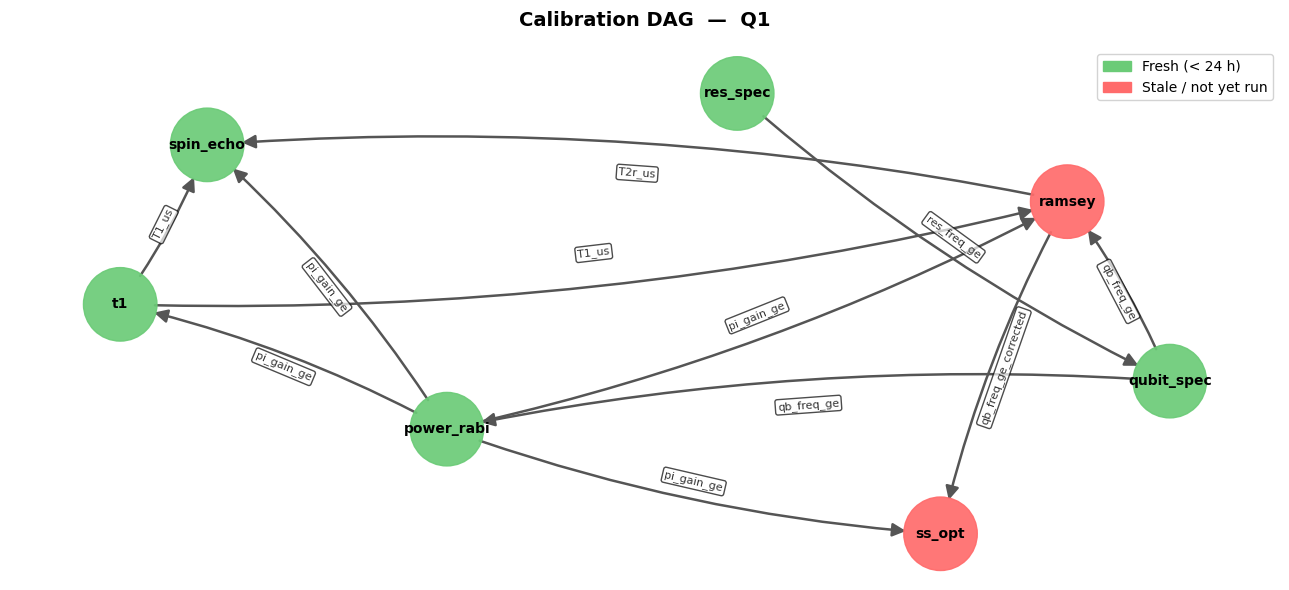

In [5]:
def plot_calibration_graph(graph: CalibrationGraph, store: CalibrationStore, qubit: str,
                           figsize=(13, 6)):
    """Draw the calibration DAG with staleness colour coding."""
    G = nx.DiGraph()

    # nodes
    for name, node in graph._nodes.items():
        G.add_node(name)

    # edges: dependency arrows (requires → node)
    provided_by = {}
    for name, node in graph._nodes.items():
        for p in node.provides:
            provided_by[p] = name
    for name, node in graph._nodes.items():
        for req in node.requires:
            provider = provided_by.get(req)
            if provider and provider != name:
                G.add_edge(provider, name, label=req)

    # staleness colours
    node_colors = []
    for name in G.nodes():
        node = graph._nodes[name]
        stale = graph._node_is_stale(node)
        node_colors.append('#FF6B6B' if stale else '#6BCB77')

    # layout: hierarchical (top → bottom)
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except Exception:
        pos = nx.spring_layout(G, seed=42, k=2.5)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'Calibration DAG  —  {qubit}', fontsize=14, fontweight='bold', pad=16)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=2800, alpha=0.92)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#555', arrows=True,
                           arrowsize=20, arrowstyle='-|>', width=1.8,
                           connectionstyle='arc3,rad=0.07',
                           min_source_margin=25, min_target_margin=25)

    # edge labels: parameter name
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                                 font_size=8, font_color='#333',
                                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

    # legend
    legend_handles = [
        mpatches.Patch(color='#6BCB77', label='Fresh (< 24 h)'),
        mpatches.Patch(color='#FF6B6B', label='Stale / not yet run'),
    ]
    ax.legend(handles=legend_handles, loc='upper right', framealpha=0.85)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_calibration_graph(graph, store, qubit)

---
## 4 — CalibrationMonitor: background staleness watcher

In [6]:
# Track which params go stale during a long session
stale_log = []  # list of (timestamp_str, "qubit/key")

def on_stale(qubit_label: str, key: str):
    ts = datetime.now().strftime('%H:%M:%S')
    msg = f'[{ts}] STALE — {qubit_label}/{key}'
    stale_log.append((ts, f'{qubit_label}/{key}'))
    print(msg)

monitor = CalibrationMonitor(
    store,
    poll_interval_s=60,       # check every 60 s
    alert_fn=on_stale,
    max_age_hours=24,
)
monitor.watch(qubit, store.all_keys(qubit))
monitor.start()
print(f'Monitor started (polling every 60 s).')
print(f'Watching {len(store.all_keys(qubit))} keys for {qubit}.')
print('Call  monitor.stop()  to shut it down.')

[CalibrationMonitor] started (poll every 60 s)
Monitor started (polling every 60 s).
Watching 10 keys for Q1.
Call  monitor.stop()  to shut it down.


In [7]:
# Inspect stale log (run any time)
if stale_log:
    print(f'Stale events so far ({len(stale_log)}):')
    for ts, key in stale_log:
        print(f'  {ts}  {key}')
else:
    print('No stale events yet.')

No stale events yet.


In [8]:
# Stop monitor when done (run this before closing the notebook)
monitor.stop()
print('Monitor stopped.')

[CalibrationMonitor] stopped
Monitor stopped.


---
## 5 — AutoCalibrate: full 7-step pipeline

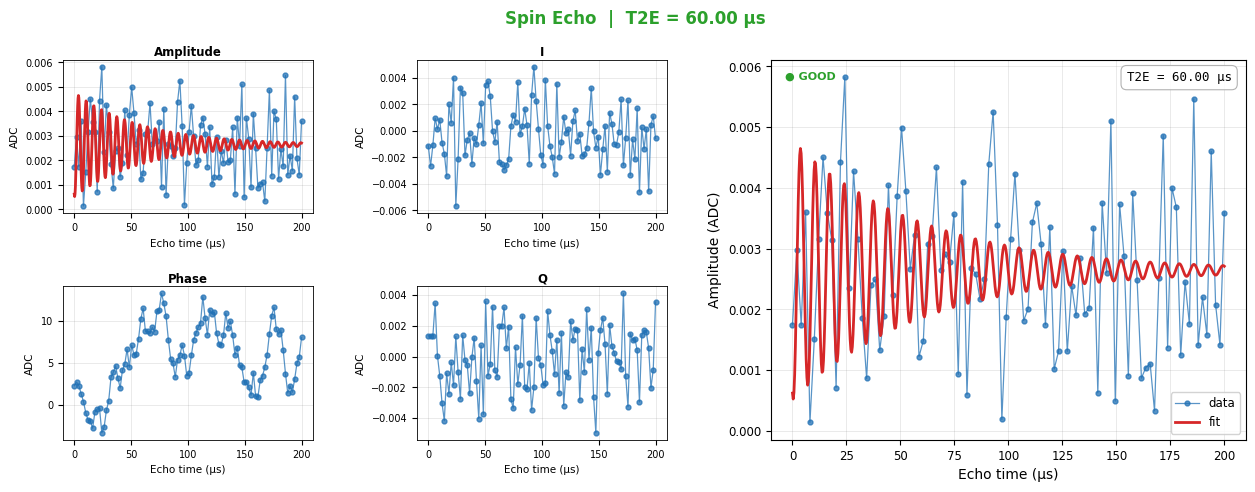

  [spin_echo] T2E=60.00 µs (stop=200 µs, ramsey_freq=0.0075 MHz)
[auto_cal] skip: ss_opt


In [9]:
# ── Run all 7 steps ──────────────────────────��─────────────────────────────���─
auto = AutoCalibrate(config_all, qubit, cal_store=store, init_guess=init_guess)

auto.run(
    skip=(
        # 'res_spec',    # uncomment to skip individual steps
        # 'qubit_spec',
        # 'power_rabi',
        # 'ramsey',
        # 'spin_echo',
        # 't1',
        'ss_opt',      # skip readout optimisation (needs many shots)
    )
)

In [10]:
# Run individual steps manually (useful for re-running a single step)
# auto.step_res_spec(span=10, steps=101, py_avg=5)
# auto.step_qubit_spec(span=50, steps=101, py_avg=5)
# auto.step_power_rabi(steps=100, py_avg=10)
# auto.step_ramsey(steps=100, py_avg=20, ramsey_freq=2.0)
# auto.step_spin_echo(steps=100, py_avg=100)
# auto.step_t1(steps=100, py_avg=50)
# auto.step_ss_opt(shots=1000)

In [11]:
auto.summary()


  Auto-Calibration Summary  —  qubit Q1
  res_freq_ge                  = 6700.01
  qb_freq_ge                   = 4999.99
  pi_gain_ge                   = 0.499634
  pi2_gain_ge                  = 0.250594
  T1_us                        = 40.1943
  T2r_us                       = 34.9023
  T2e_us                       = 60


---
## 6 — Results dashboard

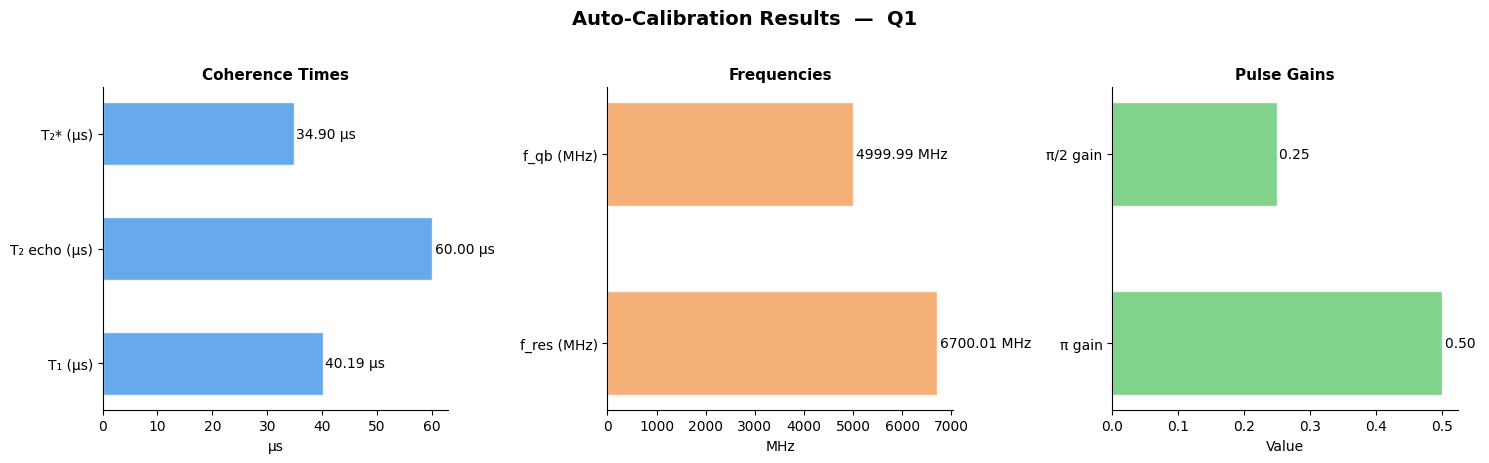


  Full results  —  Q1
  Parameter                     Value
  ---------------------------------------------
  res_freq_ge                   6700.01
  qb_freq_ge                    4999.99
  pi_gain_ge                    0.499634
  pi2_gain_ge                   0.250594
  T1_us                         40.1943
  T2r_us                        34.9023
  T2e_us                        60


In [12]:
def plot_results_dashboard(results: dict, qubit: str):
    """Bar + text summary of auto-calibration outcomes."""
    if not results:
        print('No results yet — run AutoCalibrate first.')
        return

    # ── Coherence times panel ────────────────────────────��────────────────────
    coh_keys = {'T1_us': 'T₁ (µs)', 'T2e_us': 'T₂ echo (µs)', 'T2r_us': 'T₂* (µs)'}
    coh_vals = {label: results[k] for k, label in coh_keys.items() if k in results}

    # ── Frequency panel ───────────────────────────────────────────────────────
    freq_keys = {'res_freq_ge': 'f_res (MHz)', 'qb_freq_ge': 'f_qb (MHz)'}
    freq_vals = {label: results[k] for k, label in freq_keys.items() if k in results}

    # ── Gain panel ────────────────────────────────────────────────────────────
    gain_keys = {'pi_gain_ge': 'π gain', 'pi2_gain_ge': 'π/2 gain'}
    gain_vals = {label: results[k] for k, label in gain_keys.items() if k in results}

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle(f'Auto-Calibration Results  —  {qubit}', fontsize=14, fontweight='bold', y=1.02)

    panels = [
        (axes[0], coh_vals,  'Coherence Times', '#4C9BE8', 'µs'),
        (axes[1], freq_vals, 'Frequencies',     '#F4A261', 'MHz'),
        (axes[2], gain_vals, 'Pulse Gains',     '#6BCB77', ''),
    ]

    for ax, data, title, color, unit in panels:
        ax.set_title(title, fontweight='bold', fontsize=11)
        if not data:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes,
                    fontsize=13, color='grey')
            ax.axis('off')
            continue
        labels = list(data.keys())
        values = list(data.values())
        bars = ax.barh(labels, values, color=color, alpha=0.85, edgecolor='white', height=0.55)
        for bar, val in zip(bars, values):
            label_str = f'{val:.2f} {unit}' if isinstance(val, float) else str(val)
            ax.text(val * 1.01, bar.get_y() + bar.get_height() / 2,
                    label_str, va='center', fontsize=10)
        ax.set_xlabel(unit if unit else 'Value')
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

    # ── Text table ────────────────────────────────────────────────────────────
    print(f'\n  Full results  —  {qubit}')
    print(f'  {"Parameter":<28s}  Value')
    print('  ' + '-'*45)
    for k, v in results.items():
        val_str = f'{v:.6g}' if isinstance(v, float) else str(v)
        print(f'  {k:<28s}  {val_str}')

plot_results_dashboard(auto.results, qubit)

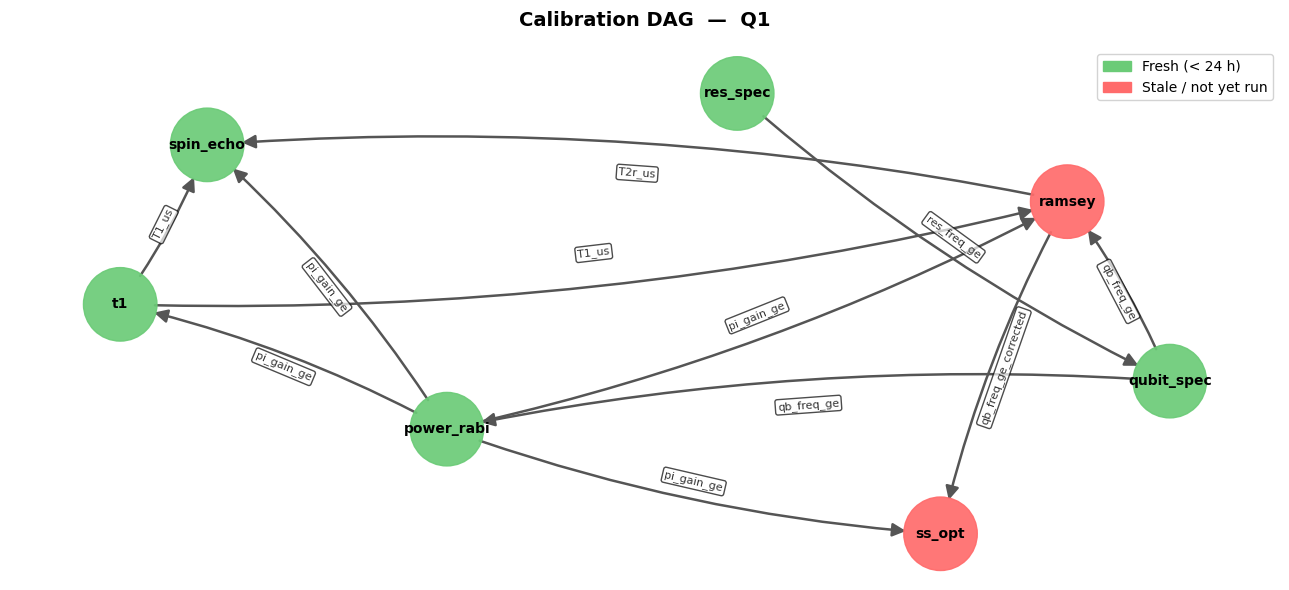

In [13]:
# Refresh the graph after calibration (nodes should now be green)
# Rebuild node stale status based on updated store
for name, node in graph._nodes.items():
    for key in node.provides:
        if key in auto.results:
            store.set(qubit, key, auto.results[key])

plot_calibration_graph(graph, store, qubit)

---
## 7 — CalibrationGraph: run only stale nodes

In [14]:
# Wire each node's run_fn to the corresponding AutoCalibrate step
# so CalibrationGraph.run_stale() can execute them automatically.

auto2 = AutoCalibrate(config_all, qubit, cal_store=store, init_guess=init_guess)

step_fns = {
    'res_spec':   auto2.step_res_spec,
    'qubit_spec': auto2.step_qubit_spec,
    'power_rabi': auto2.step_power_rabi,
    'ramsey':     auto2.step_ramsey,
    'spin_echo':  auto2.step_spin_echo,
    't1':         auto2.step_t1,
    'ss_opt':     auto2.step_ss_opt,
}

graph2 = CalibrationGraph(store, qubit)
for node in PIPELINE_NODES:
    wired = CalibrationNode(node.name, step_fns[node.name],
                            provides=node.provides, requires=node.requires)
    graph2.add(wired)

# Dry-run: see which nodes are stale without executing them
print('Dry-run — nodes that would execute:')
to_run = graph2.run_stale(max_age_hours=24, dry_run=True)
if not to_run:
    print('  All parameters are fresh — nothing to do.')

# Actual run (uncomment to execute):
# graph2.run_stale(max_age_hours=24)

Dry-run — nodes that would execute:
[dry-run] would run: ramsey (stale output)
[dry-run] would run: spin_echo (dependency changed)
[dry-run] would run: ss_opt (dependency changed)


---
## 8 — Store timeline plot


  Calibration Store  —  Q1
  Key                           Value               Age             Status
  ------------------------------------------------------------------------------
  res_freq_ge                   6700                0.0h            ✓ fresh
  qb_freq_ge                    5000                0.0h            ✓ fresh
  qb_mixer                      5000                0.0h            ✓ fresh
  sigma_ge                      0.05                0.0h            ✓ fresh
  pi_gain_ge                    0.49963             0.0h            ✓ fresh
  pi2_gain_ge                   0.25059             0.0h            ✓ fresh
  relax_delay                   201                 0.0h            ✓ fresh
  T1_us                         40.194              0.0h            ✓ fresh
  T2r_us                        34.902              0.0h            ✓ fresh
  T2e_us                        60                  0.0h            ✓ fresh


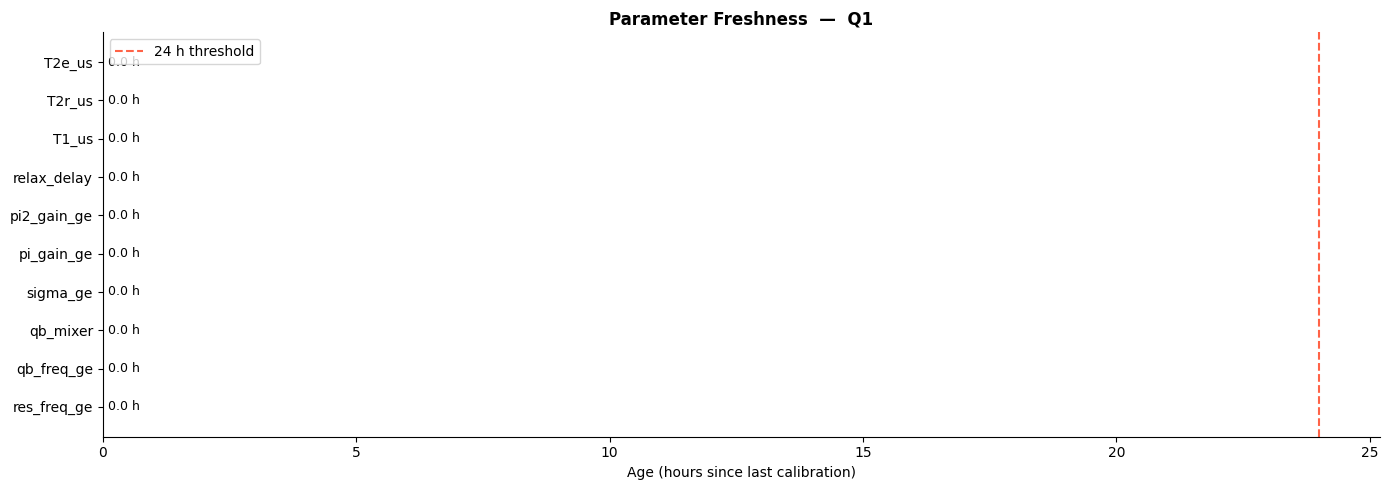

In [15]:
def plot_store_timeline(store: CalibrationStore, qubit: str, keys=None, figsize=(14, 5)):
    """
    Show the age (in hours) of each parameter in the store as a horizontal
    bar chart. Red bars indicate stale (> 24 h), green indicate fresh.
    """
    all_keys = store.all_keys(qubit)
    if keys:
        all_keys = [k for k in all_keys if k in keys]
    if not all_keys:
        print('Store is empty.')
        return

    now = datetime.now()
    ages_h, labels, colors = [], [], []
    for k in all_keys:
        entry = store._store.get(qubit, {}).get(k)
        if entry is None:
            continue
        ts  = datetime.fromisoformat(entry['timestamp'])
        age = (now - ts).total_seconds() / 3600
        ages_h.append(age)
        labels.append(k)
        colors.append('#FF6B6B' if age >= 24 else '#6BCB77')

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(labels, ages_h, color=colors, edgecolor='white', height=0.6)
    ax.axvline(24, color='tomato', linestyle='--', linewidth=1.5, label='24 h threshold')

    for bar, age in zip(bars, ages_h):
        ax.text(age + 0.1, bar.get_y() + bar.get_height() / 2,
                f'{age:.1f} h', va='center', fontsize=9)

    ax.set_xlabel('Age (hours since last calibration)')
    ax.set_title(f'Parameter Freshness  —  {qubit}', fontweight='bold', fontsize=12)
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

show_store(store, qubit)
plot_store_timeline(store, qubit)

---
## 9 — Offline / SimulatedBackend smoke test
Run every step without hardware and check the pipeline completes without errors.

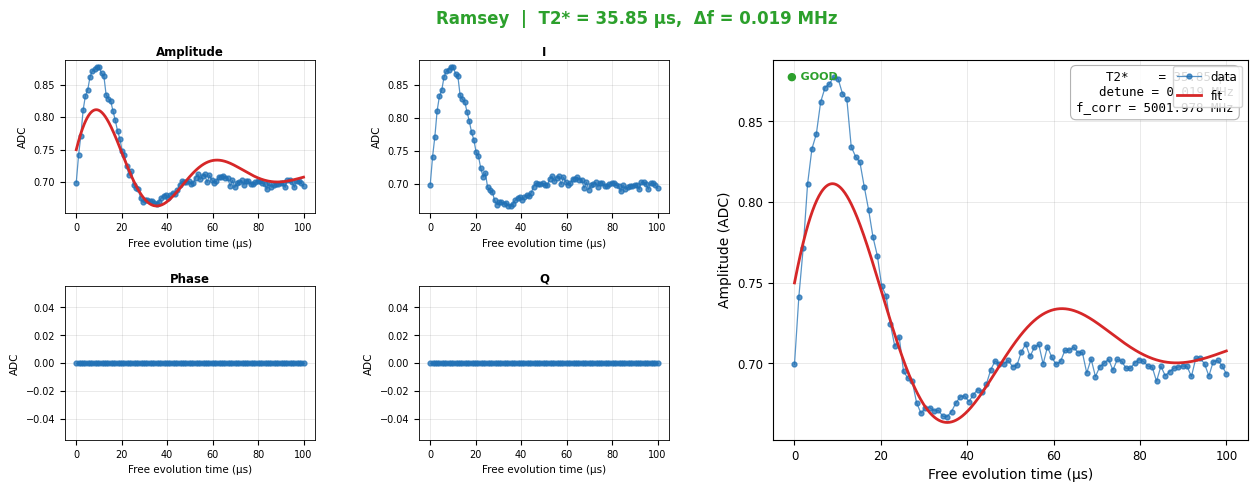

  [ramsey] attempt 5: T2*=35.85 µs, detune error=-1.9812 MHz
  [ramsey]   GP zero-crossing: 4999.9921 MHz (σ=0.0001 MHz)
  [ramsey]   → GP correction: qb_freq_ge=4999.9921 MHz
  [ramsey] did not converge in 5 attempts, proceeding
[auto_cal] skip: spin_echo
[auto_cal] skip: ss_opt

  Auto-Calibration Summary  —  qubit Q1
  res_freq_ge                  = 6699.98
  qb_freq_ge                   = 5000.01
  pi_gain_ge                   = 0.49988
  pi2_gain_ge                  = 0.250632
  T1_us                        = 40.1835
  T2r_us                       = 35.8542


c:\Users\QEL\miniforge-pypy3\envs\labberenv\lib\site-packages\sklearn\gaussian_process\kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [16]:
# Fresh config & store for the smoke test
config_test  = ExperimentConfig(config_list)
store_test   = CalibrationStore('cal_smoke.json')
auto_smoke   = AutoCalibrate(config_test, qubit, cal_store=store_test, init_guess=init_guess)

auto_smoke.run(skip=('spin_echo', 'ss_opt'))
auto_smoke.summary()

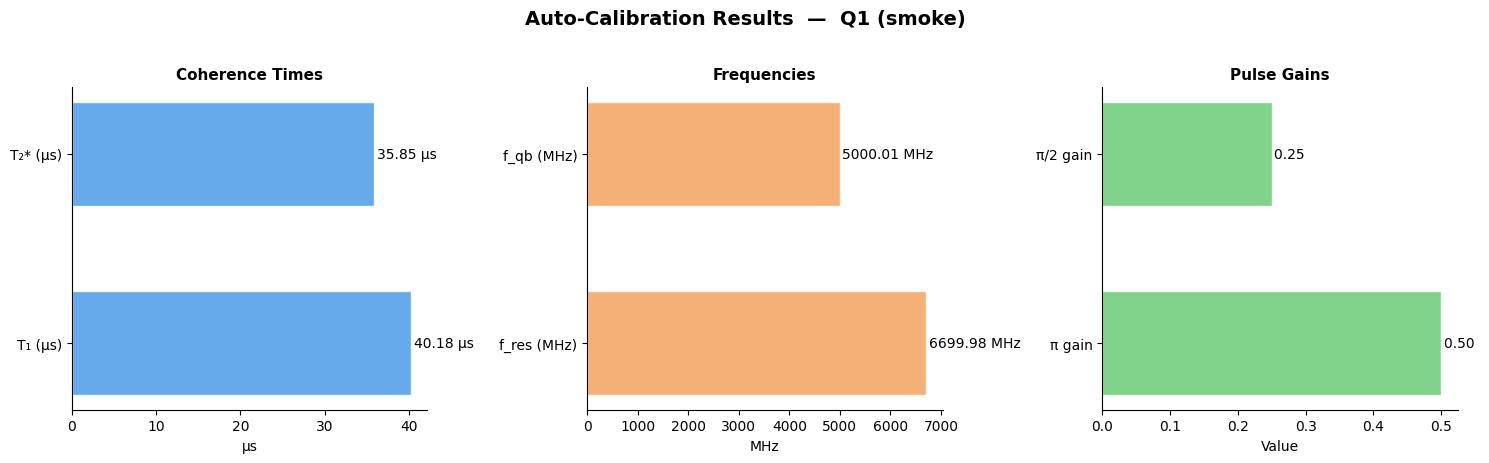


  Full results  —  Q1 (smoke)
  Parameter                     Value
  ---------------------------------------------
  res_freq_ge                   6699.98
  qb_freq_ge                    5000.01
  pi_gain_ge                    0.49988
  pi2_gain_ge                   0.250632
  T1_us                         40.1835
  T2r_us                        35.8542


In [17]:
plot_results_dashboard(auto_smoke.results, qubit + ' (smoke)')